# 132543: sensitivity-driven sparse-grid scan of an NSTX pedestal

**Purpose of this notebook.** A readable walkthrough of the scan pipeline, for
discussion. It shows where the sparse grid enters, what it scans over, and what
one function evaluation costs.

**Pipeline.**

```
   [TPED]                                       [sg_lib]
   experimental discharge (EQDSK + pfile)
        |
        |  mtanh fit of the pedestal, per species
        v
   nominal fit parameters  ------------------>  scan axes are SCALE FACTORS
        ^                                       on these fit parameters
        |                                            |
        |                                       SparseScanSession.ask()
        |                                            |  batch of grid points
        |<-------------------------------------------+
        |
        |  apply scale factors -> perturbed profiles
        |  CHEASE-BS reconstruction (bootstrap-consistent equilibrium)
        |  acceptance gate (Ip, q at the analysis radii)
        v
   per-point EQDSK + iterdb + GENE parameters file
        |
        |  GENE linear run -> growth rate at one k_y
        v
   scalar QoI  ------------------------------>  SparseScanSession.tell()
                                                    |
                                               refinement: next batch,
                                               or termination
```

`sg_lib` is the sensitivity-driven dimension-adaptive sparse-grid library
(Farcas et al., JCP 410:109394). `SparseScanSession` is our ask/tell wrapper
around it: it maps the unit hypercube to physical bounds, persists state as an
ordered (point, value) list, and rebuilds the sg_lib objects by deterministic
replay so the loop survives interpreter restarts and queue gaps.

**Status of this run.** Two things are faked so the notebook runs in minutes:

- **Only the first node is really reconstructed.** One CHEASE-BS run happens,
  then an injected stub reconstructor hands every later node the first node's
  equilibrium so the loop keeps its shape without the wait. `REAL_RECONSTRUCTIONS`
  controls how many are real.
- **No GENE.** The submitter writes the parameters file and stops; the grid is
  advanced on fabricated QoI values so it emits more than the seed point.

So the refinement trajectory, the interpolant and the later equilibria are
machinery demonstrations. The code path itself, the sampler and `_write_parameters`
included, is the production one.

Needs NERSC for the one real reconstruction: CHEASE-BS is a compiled binary.

In [1]:
# --------------------------------------------------------------- inputs
BASE_PARAMETERS = "/global/homes/j/joeschm/simulators/GENE3/NSTX_132543_omne0.8_omt0.8_KBM_r0.7/parameters"
SEED_DIRPATH    = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543"
SEED_ITERDB     = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/NSTX132543.iterdb"
SEED_GFILE      = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/g132543.00700"

OUTROOT      = "tmp_runs"
KY           = 0.05          # single k_y; the QoI is gamma at this k_y
STEPS        = 3             # refinement steps to walk (batch 0 is ONE point)
MAX_POINTS   = 12            # hard cap on nodes
REAL_RECONSTRUCTIONS = 1     # CHEASE-BS runs actually executed; later nodes
                             # reuse the first node's equilibrium via a stub
EQDSK_PREFIX = "g132543"
RECON_DIR    = None

# CHEASE-BS settings. max_iter is a physics setting, not a cost knob: the solver
# under-relaxes (bootstrap_mix 0.1, istar_mix 0.05), so a low cap returns an
# equilibrium still carrying the baseline current profile.
CHEASEBS_OVERRIDES = {
    "max_iter": 25,
    "tol_bs": 1e-4, "tol_q": 1e-4, "tol_ip_rel": 0.02,
    "bootstrap_mix": 0.1, "istar_mix": 0.05,
    "plot_errors": True,
}

In [2]:
import os, sys, json
from datetime import datetime

sys.path.insert(0, os.path.abspath("."))
import pilot_helpers as ph

WORKDIR = os.path.abspath(os.path.join(OUTROOT, datetime.now().strftime("%Y%m%d_%H-%M-%S")))
os.makedirs(WORKDIR, exist_ok=True)
with open(os.path.join(WORKDIR, "WARNING-DUMMY-SESSION.txt"), "w") as f:
    f.write("session.json here was advanced with fabricated QoI values. "
            "Do not resume a real campaign from this directory.\n")

ph.check_inputs({"BASE_PARAMETERS": BASE_PARAMETERS,
                 "SEED_ITERDB": SEED_ITERDB, "SEED_GFILE": SEED_GFILE})
print("workdir:", WORKDIR)

  BASE_PARAMETERS  ok         file: /global/homes/j/joeschm/simulators/GENE3/NSTX_132543_omne0.8_omt0.8_KBM_r0.7/parameters
  SEED_ITERDB      ok         file: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/NSTX132543.iterdb
  SEED_GFILE       ok         file: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/g132543.00700

all inputs present
workdir: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11


## 1. What the grid scans over

The scan axes are **dimensionless scale factors on the nominal mtanh fit**, not
absolute physical values. One fit per discharge, made once and reused at every
node, so the same scan coordinate means the same physics at every node.

In [3]:
from TPED.projects.discharge_tools.src.discharge_physics import DischargePhysics
from TPED.projects.discharge_tools.src.transforms.mtanh_transforms import fit_mtanh
from TPED.projects.GENE_pipelines.src.point_reconstruction import (
    PILOT_BOUNDS_132543 as BOUNDS, MTANH_AXES, MTANH_FIT_KWARGS,
    nominal_fits, _apply_axes, is_equilibrium_axis)

discharge = ph.seed_from_iterdb(SEED_ITERDB, SEED_GFILE, WORKDIR)
phys0 = DischargePhysics(discharge)

print("scan axes (scale factors on the nominal fit):\n")
print(f"{'axis':<17} {'var':<4} {'fit parameter':<15} {'range':<14} meaning")
for name, (lo, hi) in BOUNDS.items():
    var, kwarg = MTANH_AXES[name]
    meaning = {"scale_height": "pedestal step amplitude",
               "scale_width":  "pedestal width"}[kwarg]
    print(f"{name:<17} {var:<4} {kwarg:<15} [{lo}, {hi}]{'':<4} {meaning}")

print("\nnominal fit these scale (fit quality first):")
for var in sorted({v for v, _ in MTANH_AXES.values()}):
    _, record = fit_mtanh(phys0.ds, var, **MTANH_FIT_KWARGS)
    pars = "  ".join(f"{k}={v:.4g}" for k, v in record["fit_params"].items())
    print(f"  {var:<4} rms/range = {record['rms_relative']:.4f}   {pars}")

number of points: 4000
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/seed_profiles/profiles_e  (4000 points, Te in eV, ne in m^-3)
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/seed_profiles/profiles_i  (4000 points, Ti in eV, ni in m^-3)
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/seed_profiles/profiles_z  (4000 points, Tz in eV, nz in m^-3)
scan axes (scale factors on the nominal fit):

axis              var  fit parameter   range          meaning
Te_ped_scale      Te   scale_height    [0.7, 1.3]     pedestal step amplitude
ne_ped_scale      ne   scale_height    [0.7, 1.3]     pedestal step amplitude
Te_width_scale    Te   scale_width     [0.6, 1.4]     pedestal width

nominal fit these scale (fit quality first):
  Te   rms/range = 0.0052   y_sep=47.95  a_y0=147  delta_ped=0.136  psi_mid=0.903

The corners of the box, so the axes are visible as profiles. This is the whole
physical content of the scan space.

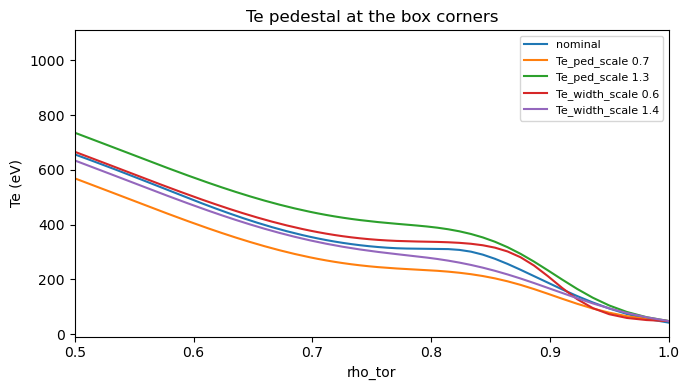

In [4]:
import matplotlib.pyplot as plt

fits = nominal_fits(phys0, set(BOUNDS))
corners = [("nominal", {})]
for axis in ("Te_ped_scale", "Te_width_scale"):
    lo, hi = BOUNDS[axis]
    corners += [(f"{axis} {lo}", {axis: lo}), (f"{axis} {hi}", {axis: hi})]

fig, ax = plt.subplots(figsize=(7, 4))
for label, point in corners:
    p = _apply_axes(phys0, point, fits=fits) if point else phys0
    ax.plot(p.rhot, p.Te, lw=1.5, label=label)
ax.set_xlim(0.5, 1.0); ax.set_xlabel("rho_tor"); ax.set_ylabel("Te (eV)")
ax.set_title("Te pedestal at the box corners"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. The sparse-grid session

`SparseScanSession` takes the axis bounds and nothing else about the physics.
`ask()` returns the next batch of surplus points in physical units; `tell()`
takes one scalar per point, in the same order. One session drives one scalar
QoI, so growth rate and frequency are separate sessions.

In [5]:
from TPED.projects.GENE_pipelines.src.sparse_scan_driver import SparseScanSession

sampler = SparseScanSession(BOUNDS, state_path=os.path.join(WORKDIR, "session.json"))

print("=" * 70)
print("[sg_lib] INPUT: the axis bounds, and nothing else")
for name, (lo, hi) in sampler.params.items():
    print(f"           {name:<17} [{lo}, {hi}]")
print(f"           dimension {sampler.dim}   tol {sampler.tol}   "
      f"max_level {sampler.max_level}")
print(f"           state file {os.path.basename(sampler.state_path)}")
print()
print("[sg_lib] OUTPUT it expects back: ONE scalar per node, in ask() order")
print("           here: gamma at k_y = %s (one session per scalar QoI;" % KY)
print("           frequency would be a second session over the same axes)")
print()
print("[sg_lib] owns: which nodes to evaluate, refinement direction,")
print("           axis sensitivity, termination, the interpolant")
print("[TPED]   owns: profiles, equilibrium, GENE inputs, running GENE,")
print("           reducing a run to the scalar")
print("=" * 70)

print(f"\n[sg_lib] ask() -> {len(sampler.ask())} node(s):")
for i, point in enumerate(sampler.ask()):
    print("           ", i, {k: round(v, 4) for k, v in point.items()})

[sg_lib] INPUT: the axis bounds, and nothing else
           Te_ped_scale      [0.7, 1.3]
           ne_ped_scale      [0.7, 1.3]
           Te_width_scale    [0.6, 1.4]
           dimension 3   tol 0.0001   max_level 10
           state file session.json

[sg_lib] OUTPUT it expects back: ONE scalar per node, in ask() order
           here: gamma at k_y = 0.05 (one session per scalar QoI;
           frequency would be a second session over the same axes)

[sg_lib] owns: which nodes to evaluate, refinement direction,
           axis sensitivity, termination, the interpolant
[TPED]   owns: profiles, equilibrium, GENE inputs, running GENE,
           reducing a run to the scalar

[sg_lib] ask() -> 1 node(s):
            0 {'Te_ped_scale': 1.0, 'ne_ped_scale': 1.0, 'Te_width_scale': 1.0}


## 3. One function evaluation

Each point from `ask()` goes through: apply the scale factors to the nominal fit
-> perturbed profiles (quasineutrality enforced) -> CHEASE-BS reconstruction
against the source EFIT boundary -> acceptance gate on Ip and on q at the two
radii the GENE runs sit at -> per-point EQDSK and iterdb -> one GENE parameters
file. A rejected point is a node the grid asked for and cannot have, which is
the interesting failure mode of a prescribed-node method.

In [6]:
from TPED.projects.discharge_tools.src.cheasebs_runner import CheasebsAcceptance
from TPED.projects.GENE_pipelines.src.scan_campaign import (
    GeneScanCampaign, QoISpec, HARVESTED, REJECTED)

GENE_RADII = (0.736, 0.825)      # r_0.736 (q=4), r_0.825 (q=5)
AXIS_SHORT = {"Te_ped_scale": "Te", "ne_ped_scale": "ne", "Te_width_scale": "wTe"}

campaign = GeneScanCampaign(
    sampler=sampler,
    base_discharge=discharge,
    qoi=QoISpec(quantity="gamma", reduction="at_ky", ky=KY),
    workdir=WORKDIR,
    base_parameters=os.path.abspath(BASE_PARAMETERS),
    acceptance=CheasebsAcceptance.production(analysis_radii=GENE_RADII),
    ky_scanlist=[KY],
    recon_dir=RECON_DIR,
    cheasebs_overrides=CHEASEBS_OVERRIDES,
)
campaign.submitter = ph.write_parameters_only(campaign)   # writes parameters, does not submit
print("campaign ready")

campaign ready


### Skipping the reconstructions

Only `REAL_RECONSTRUCTIONS` nodes get a real CHEASE-BS run. After that an
injected stub reconstructor hands each node the first node's equilibrium, so the
loop, the parameters writer and the refinement all keep working without the
wait. Nodes served by the stub are marked `STUB` everywhere below: their
equilibria are not theirs.

In [7]:
import shutil
from TPED.projects.GENE_pipelines.src.point_reconstruction import ReconstructionResult

def stub_reconstructor(reference):
    """Accept every node, copying *reference*'s equilibrium. No CHEASE-BS.

    Copies rather than shares the paths: retag_eqdsks() renames each node's
    EQDSK in place, so shared paths would rename the reference out from under
    the next node.
    """
    ref_eqdsk, ref_iterdb = reference.eqdsk, reference.iterdb

    def _reconstruct(point, base_discharge, savedir, point_id=None, acceptance=None):
        os.makedirs(savedir, exist_ok=True)
        eqdsk = os.path.join(savedir, os.path.basename(ref_eqdsk))
        shutil.copy2(ref_eqdsk, eqdsk)
        iterdb = None
        if ref_iterdb and os.path.exists(ref_iterdb):
            iterdb = os.path.join(savedir, os.path.basename(ref_iterdb))
            shutil.copy2(ref_iterdb, iterdb)
        return ReconstructionResult(
            point_id=point_id, point=dict(point), accepted=True,
            eqdsk=eqdsk, iterdb=iterdb, savedir=savedir,
            acceptance={"accepted": True, "stub": True,
                        "cheasebs_iterations": None, "cheasebs_converged": None,
                        "ip_error_rel": None,
                        "note": f"copied from {reference.point_id}"})
    return _reconstruct

def install_stub_if_due(campaign, real_done):
    if campaign.reconstructor is not None or real_done < REAL_RECONSTRUCTIONS:
        return False
    ref = next((e for e in campaign.ledger.entries.values() if e.eqdsk), None)
    if ref is None:
        return False
    campaign.reconstructor = stub_reconstructor(ref)
    print(f"[TPED]   CHEASE-BS off after {real_done} run(s); later nodes reuse "
          f"{ref.point_id}'s equilibrium")
    return True

print("stub ready, not installed yet")

stub ready, not installed yet


## 4. The ask/tell loop

The handoff, per step: `[sg_lib] ask()` gives nodes, `[TPED]` turns each into a
GENE-ready run directory, `[sg_lib] tell()` takes one scalar back per node and
decides where to refine. In production the scalars are harvested growth rates;
here they are fabricated.


[sg_lib] ask() -> 1 node(s) at step 0
           Te=1.0000  wTe=1.0000  ne=1.0000
[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27-16-b0000p0000/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27-16-b0000p0000
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27-16-b0000p0000/cheasebs_baseline
Run targets: Ip=947061.789 A (source 947061.789 A), Bt=-0.439262 T (source -0.439262 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g132543.00700
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decomposition
Baseline outputs written
Baseline rebuild complete: /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27

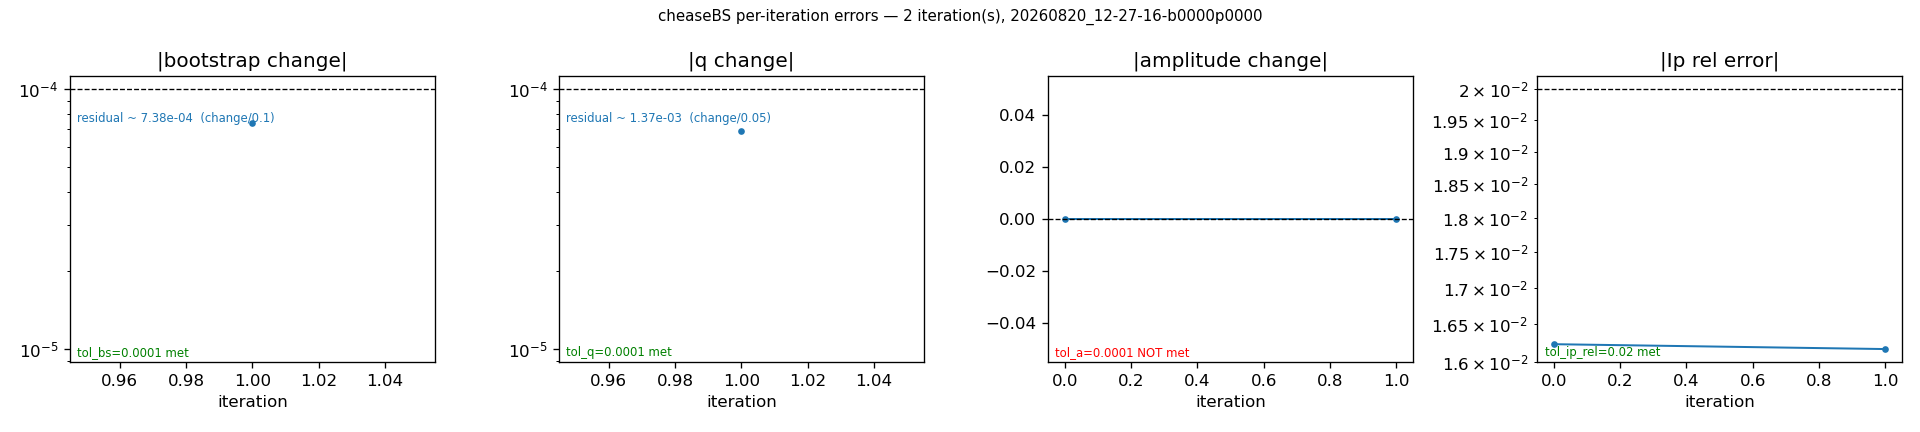

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27-16-b0000p0000/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.617%  (final 931749.1 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.613%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.514%   (deviation from source)
[cheaseBS]   q95 error        0.836%
[cheaseBS]   q edge error    16.921%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260820_12-27-16-b0000p0000
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/_reconstruction/b0000p0000/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
[TPED]   1/1 node(s) accepted by the gate
[TPED]     b0000p0000  cheaseBS iters=2  Ip err=1.617%  -> b0000p0000
[sg_lib] tell() <- ['0

In [8]:
proposed, real_done = 0, 0
for step in range(STEPS):
    install_stub_if_due(campaign, real_done)

    asked = campaign.sampler.ask()
    print(f"\n{'=' * 70}\n[sg_lib] ask() -> {len(asked)} node(s) at step {step}")
    for point in asked:
        print("           " + "  ".join(f"{AXIS_SHORT.get(k, k)}={v:.4f}"
                                        for k, v in sorted(point.items())))

    accepted = campaign.propose()
    batch = campaign.ledger.batch(step)
    proposed += len(batch)
    if campaign.reconstructor is None:
        real_done += len(batch)

    print(f"[TPED]   {len(accepted)}/{len(batch)} node(s) accepted by the gate")
    ph.retag_eqdsks(campaign, step, EQDSK_PREFIX, AXIS_SHORT)
    campaign.submit_pending()
    for e in batch:
        a = e.acceptance or {}
        ip = a.get("ip_error_rel")
        ip = f"Ip err={ip:.3%}" if isinstance(ip, (int, float)) else "Ip err=n/a"
        tag = "STUB" if a.get("stub") else f"cheaseBS iters={a.get('cheasebs_iterations')}"
        if e.status == REJECTED:
            print(f"[TPED]     {e.point_id}  REJECTED: {e.note}")
        else:
            print(f"[TPED]     {e.point_id}  {tag}  {ip}  -> "
                  f"{os.path.basename(e.rundir or '(no rundir)')}")

    stuck = [e for e in batch if not e.rundir and e.eqdsk]
    if stuck:
        print(f"STOP: {len(stuck)} node(s) wrote no parameters file"); break
    if len(accepted) != len(batch):
        print("STOP: batch incomplete, so the grid cannot advance"); break

    # In production this value is gamma harvested from the GENE run.
    for e in batch:
        campaign.ledger.update(e.point_id, status=HARVESTED,
                               qoi=ph.dummy_qoi(e.point), note="DUMMY_QOI")
    values = campaign.tell_batch(step)
    print(f"[sg_lib] tell() <- {['%.4g' % v for v in values]}   (fabricated)")
    print(f"[sg_lib] evals now {campaign.sampler.n_evals}, "
          f"levels {campaign.sampler.axis_refinement_levels()}, "
          f"finished={campaign.sampler.finished}")

    if proposed >= MAX_POINTS:
        print(f"STOP: node cap {MAX_POINTS}"); break

## 5. Did every node evaluate?

The question a prescribed-node method makes sharp: a node we cannot deliver is
a hole in the interpolant, not a noisy label. Two ways to lose one here, and
both are visible below: CHEASE-BS fails to converge, or the acceptance gate
rejects the equilibrium it produced.

Only the first row is a real reconstruction in this run; the rest report `None`
iterations because the stub served them.

In [9]:
ph.convergence_report(campaign)

problems = ph.verify_parameters(campaign, is_equilibrium_axis)
print("\nparameters-file check:",
      "clean" if not problems else f"{len(problems)} problem(s): {problems}")

point_id      iters  solver conv     Ip err     gate
----------------------------------------------------
b0000p0000        2         True     1.617%   accept
b0001p0000     None         None        n/a   accept
b0001p0001     None         None        n/a   accept
b0001p0002     None         None        n/a   accept
b0002p0000     None         None        n/a   accept

iterations: min 2, max 2

parameters-file check: 5 problem(s): [('b0000p0000', "iterdb_file is not this point's iterdb"), ('b0001p0000', "iterdb_file is not this point's iterdb"), ('b0001p0001', "iterdb_file is not this point's iterdb"), ('b0001p0002', "iterdb_file is not this point's iterdb"), ('b0002p0000', "iterdb_file is not this point's iterdb")]


## 6. Grid state

`axis_refinement_levels()` is the axis-importance readout: an axis left at level
1 was never refined, i.e. pruned. `surrogate()` returns the interpolant over the
multi-indices whose evaluations are in hand, callable mid-scan.

In [10]:
print(f"[sg_lib] evaluations used   {sampler.n_evals}")
print(f"[sg_lib] finished           {sampler.finished}")
print(f"[sg_lib] refinement levels  {sampler.axis_refinement_levels()}")

print("\n[sg_lib] everything the grid holds: its inputs, and one QoI each")
print("         (QoI = gamma at k_y = %s -- fabricated in this run)" % KY)
print(f"{'#':>3}  " + "  ".join(f"{AXIS_SHORT.get(n, n):>7}" for n in sampler.names) + "      QoI")
for i, (std, value) in enumerate(sampler._evals):
    phys = [lo + s * (hi - lo) for s, (lo, hi) in zip(std, sampler.params.values())]
    print(f"{i:>3}  " + "  ".join(f"{v:>7.3f}" for v in phys) + f"   {value:>10.4g}")

[sg_lib] evaluations used   5
[sg_lib] finished           False
[sg_lib] refinement levels  {'Te_ped_scale': 2, 'ne_ped_scale': 3, 'Te_width_scale': 3}

[sg_lib] everything the grid holds: its inputs, and one QoI each
         (QoI = gamma at k_y = 0.05 -- fabricated in this run)
  #       Te       ne      wTe      QoI
  0    1.000    1.000    1.000       0.8467
  1    1.300    1.000    1.000      0.01783
  2    1.000    1.300    1.000        -1.64
  3    1.000    1.000    1.400       -1.179
  4    1.000    0.700    1.000        3.013


In [11]:
# 1-D slices of the interpolant through the nominal point. Shape is meaningless
# here (fabricated QoI) -- this is the interpolant call, not a result.
import numpy as np

try:
    f = sampler.surrogate()
    nominal = {n: 1.0 for n in sampler.names}
    fig, axes = plt.subplots(1, sampler.dim, figsize=(4 * sampler.dim, 3), sharey=True)
    for ax, name in zip(np.atleast_1d(axes), sampler.names):
        lo, hi = sampler.params[name]
        xs = np.linspace(lo, hi, 60)
        ys = [f([xs[k] if n == name else nominal[n] for n in sampler.names])
              for k in range(len(xs))]
        ax.plot(xs, ys); ax.set_xlabel(AXIS_SHORT.get(name, name))
    np.atleast_1d(axes)[0].set_ylabel("interpolant (fabricated QoI)")
    plt.tight_layout(); plt.show()
except RuntimeError as exc:
    print("no interpolant yet:", exc)

## 7. What one node hands to GENE

A run directory holding a GENE run and nothing else: the parameters file, its
own EQDSK, its own iterdb. Reconstruction artifacts stay out, so the directory
can be tarred and moved.

In [12]:
written = [e for e in campaign.ledger.entries.values() if e.rundir]
if written:
    e = written[0]
    print(e.rundir)
    for f in sorted(os.listdir(e.rundir)):
        print("   ", f)
    print("\n" + open(os.path.join(e.rundir, "parameters")).read())
else:
    print("nothing written")

/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/b0000p0000
    g132543_Te1.000-wTe1.000-ne1.000
    parameters
    profiles.iterdb

&parallelization
n_procs_s = 1
n_procs_v = 1
n_procs_w = 4
n_procs_x = 1
n_procs_y = 1
n_procs_z = 1
n_procs_sim = 4
n_parallel_sims = 6
/

&box
n_spec = 3
nx0 = 3
nky0 = 1
nz0 = 64
nv0 = 36
nw0 = 32
n0_global = 1 !scanlist: 10, 20, 30, 50, 70, 100
lv = 3.0
lw = 9
lx = 129
adapt_lx = T
adapt_ly = T
x0 = 0.7
kymin = 0.05 !scanlist: 0.05
/

&in_out
diagdir = '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/b0000p0000'
read_checkpoint = F
write_checkpoint = T
istep_field = 100
istep_mom = 100
istep_nrg = 100
istep_vsp = 400
istep_schpt = 5000
iterdb_file = '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/b0000p0000/profiles.iterdb'
/

&general
nblocks = 1
perf_vec = '1 1 1 1 1 1 1 1 2'
calc_dt = T
nonlinear = F
comp_type

In [13]:
summary = os.path.join(WORKDIR, "walkthrough_summary.json")
with open(summary, "w") as f:
    json.dump({"workdir": WORKDIR, "axes": BOUNDS, "ky": KY,
               "analysis_radii": list(GENE_RADII),
               "qoi_values_are_fabricated": True,
               "n_evals": sampler.n_evals,
               "refinement_levels": sampler.axis_refinement_levels(),
               "problems": problems,
               "points": [{"point_id": e.point_id, "batch": e.batch,
                           "point": e.point, "status": e.status,
                           "rundir": e.rundir, "note": e.note}
                          for e in campaign.ledger.entries.values()]}, f, indent=1)
print(summary)

/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260820_12-27-11/walkthrough_summary.json
